# Machine Learning Models - Final Project
## Anshul Satav

Acknowledgement: I received help from ChatGPT in some parts

In [86]:
# importing the libraries needed
import pandas as pd
import numpy as np 

# run this line if you haven't installed the library yet
# pip install pandas_ta
import pandas_ta

In [87]:
df = pd.read_csv("C:/Users/anshu/OneDrive - Grinnell College/ts_anshul_data.csv")
df

,Date,DFF_ind,cels_ind,nqrobous_ind,djusen_ind,sp500_ind,Year
0,2021-01-04,0.09,925.770710,1856.982209,315.91,3700.70,2021
1,2021-01-05,0.09,946.618225,1883.424603,329.94,3726.90,2021
2,2021-01-06,0.09,1006.793392,1884.061442,340.04,3748.10,2021
3,2021-01-07,0.09,1074.584820,1975.754474,345.32,3803.80,2021
4,2021-01-08,0.09,1091.901275,2006.714851,344.67,3824.70,2021
...,...,...,...,...,...,...,...
1250,2025-12-24,3.64,610.335327,2231.657339,749.04,6932.05,2025
1251,2025-12-26,3.64,606.578406,2217.540981,746.74,6929.94,2025
1252,2025-12-29,3.64,596.288427,2204.160058,753.74,6905.74,2025
1253,2025-12-30,3.64,586.992524,2193.468862,759.24,6896.24,2025


In [88]:
# nqrobous feature generation 
df['nqrobous_ind_lag1'] = df['nqrobous_ind'].shift(1)
df['nqrobous_ind_lag2'] = df['nqrobous_ind'].shift(2)
df['nqrobous_ind_lag3'] = df['nqrobous_ind'].shift(3)


# cels feature generation
df['cels_ind_lag1'] = df['cels_ind'].shift(1)
df['cels_ind_lag2'] = df['cels_ind'].shift(2)
df['cels_ind_lag3'] = df['cels_ind'].shift(3)


# djusen feature generation
df['djusen_ind_lag1'] = df['djusen_ind'].shift(1)
df['djusen_ind_lag2'] = df['djusen_ind'].shift(2)
df['djusen_ind_lag3'] = df['djusen_ind'].shift(3)

# dff feature generation
df['dff_lag1'] = df['DFF_ind'].shift(1)
df['dff_lag2'] = df['DFF_ind'].shift(2)
df['dff_lag3'] = df['DFF_ind'].shift(3)

# sp500 feature generation
df['sp500_lag1'] = df['sp500_ind'].shift(1)
df['sp500_lag2'] = df['sp500_ind'].shift(2)
df['sp500_lag3'] = df['sp500_ind'].shift(3)

#Technical Indicators
# Citation -> this function to calculate indicators was adopted from my previous project on stock price prediction using technical indicators.
# https://github.com/anshulsatav/stockpredictions-analysis/blob/main/EDA-LSTM-techinds.ipynb
# rsi generation 
df['nqrobous_rsi'] = pandas_ta.rsi(df['nqrobous_ind'], length=10)
df['cels_rsi'] = pandas_ta.rsi(df['cels_ind'], length=10)
df['djusen_rsi'] = pandas_ta.rsi(df['djusen_ind'], length=10)
df['sp500_rsi'] = pandas_ta.rsi(df['sp500_ind'], length=10)

# simple moving averages
df['nqrobous_sma'] = pandas_ta.sma(df['nqrobous_ind'], length=10)
df['cels_sma'] = pandas_ta.sma(df['cels_ind'], length=10)
df['djusen_sma'] = pandas_ta.sma(df['djusen_ind'], length=10)
df['sp500_sma'] = pandas_ta.sma(df['sp500_ind'], length=10)

#exponential moving averages
df['nqrobous_ema'] = pandas_ta.ema(df['nqrobous_ind'], length=10)
df['cels_ema'] = pandas_ta.ema(df['cels_ind'], length=10)
df['djusen_ema'] = pandas_ta.ema(df['djusen_ind'], length=10)
df['sp500_ema'] = pandas_ta.ema(df['sp500_ind'], length=10) 

# dropping the na values generated due to feature generation
df = df.dropna()


In [89]:
df.head(2)

,Date,DFF_ind,cels_ind,nqrobous_ind,djusen_ind,sp500_ind,Year,nqrobous_ind_lag1,nqrobous_ind_lag2,nqrobous_ind_lag3,...,djusen_rsi,sp500_rsi,nqrobous_sma,cels_sma,djusen_sma,sp500_sma,nqrobous_ema,cels_ema,djusen_ema,sp500_ema
9,2021-01-15,0.09,1055.383594,2026.315292,355.49,3768.2,2021,2059.892713,1998.679132,2004.561800,...,83.940173,75.335628,1970.727893,1054.260658,347.346,3777.85,1970.727893,1054.260658,347.346000,3777.850000
10,2021-01-19,0.09,1107.431648,2088.857486,362.45,3798.9,2021,2026.315292,2059.892713,1998.679132,...,85.020819,78.525544,1993.915421,1072.426752,352.000,3787.67,1992.206001,1063.928111,350.092182,3781.677273


In [90]:
# separating the training and testing data
train_df = df[df["Year"] < 2025]
test_df = df[df["Year"] == 2025]

# dropping variables for the baseline model and separating the features and target variable for training and testing data
train_X = train_df.drop(columns=["Year", "nqrobous_ind",  "Date", 
                                 "nqrobous_ind_lag2", "nqrobous_ind_lag3",
                                  "cels_ind_lag2", "cels_ind_lag3",
                                     "djusen_ind_lag2", "djusen_ind_lag3", 
                                    "nqrobous_rsi", "cels_rsi", "djusen_rsi", "sp500_rsi",
                                    "nqrobous_sma", "cels_sma", "djusen_sma", "sp500_sma",
                                    "nqrobous_ema", "cels_ema", "djusen_ema", "sp500_ema", "sp500_lag1", "dff_lag2",
                                      "sp500_lag2", "sp500_lag3", "dff_lag1", "dff_lag3"])

train_Y = train_df["nqrobous_ind"]

test_X = test_df.drop(columns=["Year", "nqrobous_ind",  "Date", 
                                 "nqrobous_ind_lag2", "nqrobous_ind_lag3",
                                  "cels_ind_lag2", "cels_ind_lag3",
                                     "djusen_ind_lag2", "djusen_ind_lag3", 
                                    "nqrobous_rsi", "cels_rsi", "djusen_rsi", "sp500_rsi",
                                    "nqrobous_sma", "cels_sma", "djusen_sma", "sp500_sma",
                                    "nqrobous_ema", "cels_ema", "djusen_ema", "sp500_ema", "sp500_lag1", "dff_lag2",
                                      "sp500_lag2", "sp500_lag3", "dff_lag1", "dff_lag3"
                                    ])
test_Y = test_df["nqrobous_ind"]

In [91]:
train_X

,DFF_ind,cels_ind,djusen_ind,sp500_ind,nqrobous_ind_lag1,cels_ind_lag1,djusen_ind_lag1
9,0.09,1055.383594,355.49,3768.20,2059.892713,1118.403303,369.94
10,0.09,1107.431648,362.45,3798.90,2026.315292,1055.383594,355.49
11,0.09,1093.682883,363.44,3851.80,2088.857486,1107.431648,362.45
12,0.08,1121.078361,351.55,3853.10,2122.606158,1093.682883,363.44
13,0.08,1133.430499,349.85,3841.50,2128.107457,1121.078361,351.55
...,...,...,...,...,...,...,...
1000,4.33,468.606997,712.49,6040.04,1932.179355,460.355190,707.30
1001,4.33,467.868071,711.45,6037.59,1951.616890,468.606997,712.49
1002,4.33,459.234661,711.41,5970.84,1959.986619,467.868071,711.45
1003,4.33,450.874048,712.12,5906.94,1934.508320,459.234661,711.41


In [92]:
# importing the xgboost regressor, if you haven't installed it yet, run the line below
# !pip install xgboost
from xgboost import XGBRegressor
# importing the metrics to evaluate the model performance
from sklearn.metrics import mean_squared_error, mean_absolute_error

# making the initial model and fitting it to the training data
model = XGBRegressor()
model.fit(train_X, train_Y)

# generating predictions on the testing data and evaluating the model performance using RMSE and MAE
predictions = model.predict(test_X)
rmse = np.sqrt(mean_squared_error(test_Y, predictions))
print("Root Mean Squared Error:", rmse)

mae = mean_absolute_error(test_Y, predictions)
print("Mean Absolute Error:", mae)

Root Mean Squared Error: 75.10379383390234
Mean Absolute Error: 55.00199386110142


In [93]:
# hyperparameter tuning using grid search to find the optimal parameters

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# define time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)
# Define the hyperparameters 
param = [
    { "n_estimators": [200,400,600],
     "max_depth": [3,4,5],
        "learning_rate": [0.01, 0.05, 0.1],
        "random_state": [1234]}
]

# Perform 5 CV grid search
grid_search = GridSearchCV(model, 
                           param,
                           cv =tscv,
                           scoring = "neg_root_mean_squared_error").fit(train_X, train_Y)

# using the best model from grid search to forecast and evaluating model performance
predictions = grid_search.best_estimator_.predict(test_X)
rmse = np.sqrt(mean_squared_error(test_Y, predictions))
print("Root Mean Squared Error:", rmse)

mae = mean_absolute_error(test_Y, predictions)
print("Mean Absolute Error:", mae)

Root Mean Squared Error: 67.9769477675384
Mean Absolute Error: 46.05075028471899


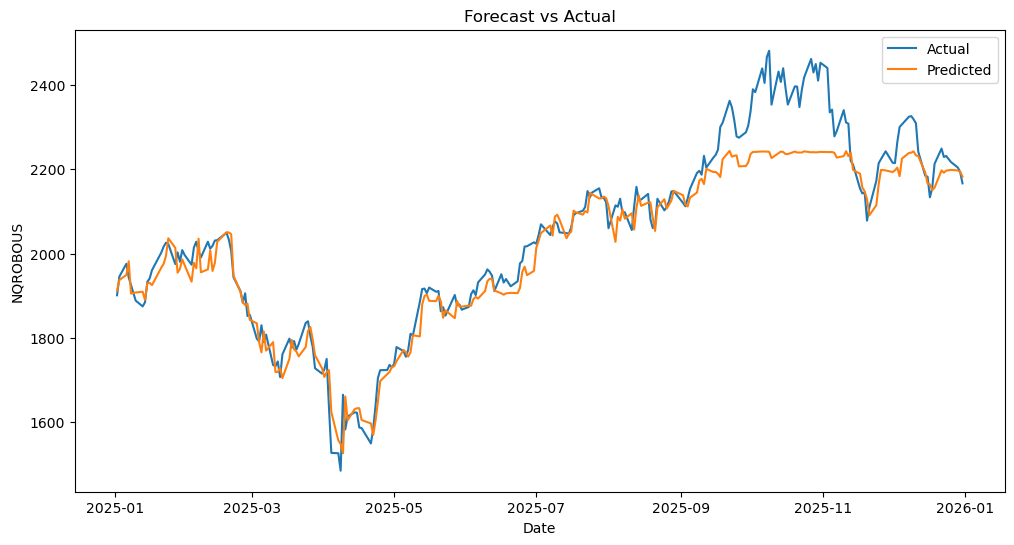

In [94]:
# importing the library to generate a plot for forecasts vs actual values
import matplotlib.pyplot as plt

# Forecast vs Actual plot for nqrobous_diff on test set
# Converting to date for cleaner x-axis 
x = pd.to_datetime(test_df['Date'])
plt.figure(figsize=(12,6))
plt.plot(x, test_Y.values, label='Actual')
plt.plot(x, predictions, label='Predicted')
plt.xlabel('Date')
plt.ylabel('NQROBOUS')
plt.title('Forecast vs Actual')
plt.legend()
plt.show()

In [95]:
# generating feature importances(not yet used in the paper)
importance = pd.DataFrame({
    'feature': train_X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance)

             feature  importance
4  nqrobous_ind_lag1    0.989013
3          sp500_ind    0.004403
1           cels_ind    0.002066
5      cels_ind_lag1    0.001525
6    djusen_ind_lag1    0.001206
2         djusen_ind    0.001052
0            DFF_ind    0.000735


In [96]:
# importing the SVR model
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler    

# scaling the features for SVR model as it is a distance based model
scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_X)
test_X_scaled = scaler.transform(test_X)

# training the initial model and evaluating performance
model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)
model.fit(train_X_scaled, train_Y)
predictions = model.predict(test_X_scaled)
rmse = np.sqrt(mean_squared_error(test_Y, predictions))
print("Root Mean Squared Error:", rmse)

mae = mean_absolute_error(test_Y, predictions)
print("Mean Absolute Error:", mae)

Root Mean Squared Error: 145.11414966924457
Mean Absolute Error: 98.81676704398315


In [97]:
# Define the hyperparameters 
param = [
    { "kernel": ['rbf', 'linear'],
     "C": [10, 100, 1000],
    "gamma": [0.01, 0.1, 1]}
]

# Perform 5 CV grid search
grid_search = GridSearchCV(model, 
                           param,
                           cv = tscv,
                           scoring = "neg_root_mean_squared_error").fit(train_X_scaled, train_Y)

# using the best model from grid search to forecast and evaluating model performance

predictions = grid_search.best_estimator_.predict(test_X_scaled)
rmse = np.sqrt(mean_squared_error(test_Y, predictions))
print("Root Mean Squared Error:", rmse)

mae = mean_absolute_error(test_Y, predictions)
print("Mean Absolute Error:", mae)

Root Mean Squared Error: 25.606026447502
Mean Absolute Error: 19.43957519424365


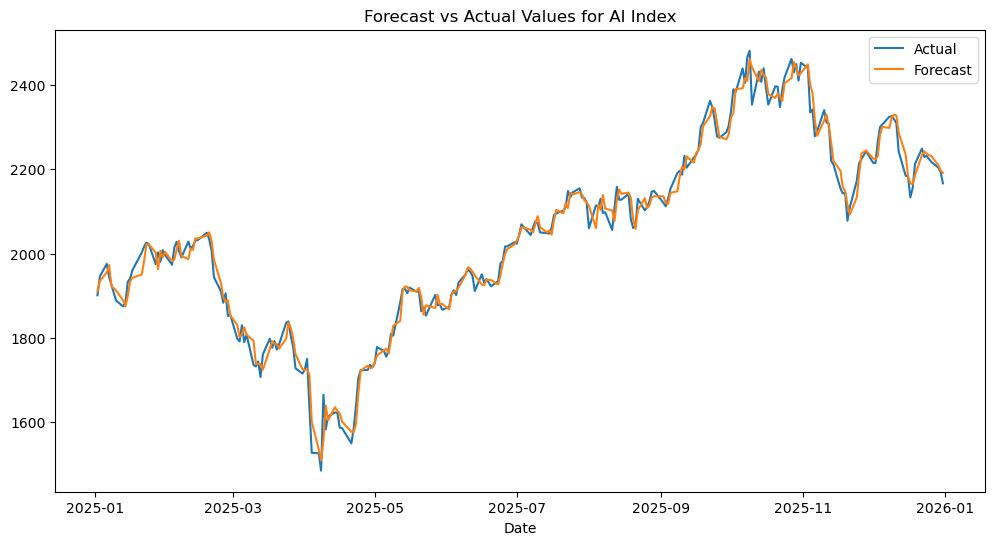

In [ ]:
# Forecast vs Actual plot for nqrobous on test set
# Figure 11
x = pd.to_datetime(test_df['Date'])
plt.figure(figsize=(12,6))
plt.plot(x, test_Y.values, label='Actual')
plt.plot(x, predictions, label='Forecast')
plt.xlabel('Date')
plt.title('Forecast vs Actual Values for AI Index')
plt.legend()
plt.show()

In [99]:
# generating new training and testing data for feature engineered models 
train_X2 = train_df.drop(columns=["Year", "nqrobous_ind",  "Date"
                                    ])

train_Y2 = train_df["nqrobous_ind"]
test_X2 = test_df.drop(columns=["Year", "nqrobous_ind",  "Date"
                                    ])
test_Y2 = test_df["nqrobous_ind"]

In [100]:
train_X2

,DFF_ind,cels_ind,djusen_ind,sp500_ind,nqrobous_ind_lag1,nqrobous_ind_lag2,nqrobous_ind_lag3,cels_ind_lag1,cels_ind_lag2,cels_ind_lag3,...,djusen_rsi,sp500_rsi,nqrobous_sma,cels_sma,djusen_sma,sp500_sma,nqrobous_ema,cels_ema,djusen_ema,sp500_ema
9,0.09,1055.383594,355.49,3768.20,2059.892713,1998.679132,2004.561800,1118.403303,1119.212263,1120.017728,...,83.940173,75.335628,1970.727893,1054.260658,347.346,3777.850,1970.727893,1054.260658,347.346000,3777.850000
10,0.09,1107.431648,362.45,3798.90,2026.315292,2059.892713,1998.679132,1055.383594,1118.403303,1119.212263,...,85.020819,78.525544,1993.915421,1072.426752,352.000,3787.670,1992.206001,1063.928111,350.092182,3781.677273
11,0.09,1093.682883,363.44,3851.80,2088.857486,2026.315292,2059.892713,1107.431648,1055.383594,1118.403303,...,85.178442,82.787650,2017.833577,1087.133218,355.350,3800.160,2015.915120,1069.338069,352.519058,3794.426860
12,0.08,1121.078361,351.55,3853.10,2122.606158,2088.857486,2026.315292,1093.682883,1107.431648,1055.383594,...,74.690272,82.880427,2042.238178,1098.561714,356.501,3810.660,2036.313727,1078.745395,352.342866,3805.094703
13,0.08,1133.430499,349.85,3841.50,2128.107457,2122.606158,2088.857486,1121.078361,1093.682883,1107.431648,...,73.257275,78.675930,2058.992116,1104.446282,356.954,3814.430,2055.764659,1088.688141,351.889617,3811.713848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000,4.33,468.606997,712.49,6040.04,1932.179355,1922.712313,1897.346917,460.355190,453.940988,444.996367,...,30.332504,56.064811,1961.756748,464.680898,721.769,5999.542,1952.302668,462.265531,721.397106,5990.746964
1001,4.33,467.868071,711.45,6037.59,1951.616890,1932.179355,1922.712313,468.606997,460.355190,453.940988,...,29.842512,55.705945,1958.101851,464.074526,717.517,5994.882,1953.699750,463.284175,719.588541,5999.263880
1002,4.33,459.234661,711.41,5970.84,1959.986619,1951.616890,1932.179355,467.868071,468.606997,460.355190,...,29.821925,46.663911,1951.922110,463.067517,713.781,5986.841,1950.210399,462.547899,718.101534,5994.095902
1003,4.33,450.874048,712.12,5906.94,1934.508320,1959.986619,1951.616890,459.234661,467.868071,468.606997,...,30.763930,39.793486,1943.135696,460.966607,710.606,5972.426,1942.143348,460.425381,717.013982,5978.249374


In [101]:
# training the initial model and evaluating performance
model = XGBRegressor()
model.fit(train_X2, train_Y2)
predictions = model.predict(test_X2)
rmse = np.sqrt(mean_squared_error(test_Y2, predictions))
print("Root Mean Squared Error:", rmse)

mae = mean_absolute_error(test_Y2, predictions)
print("Mean Absolute Error:", mae)

Root Mean Squared Error: 82.54409181467835
Mean Absolute Error: 56.72552200812956


In [102]:
# defining the hyperparameters for grid search
param = [
    { "n_estimators": [200,400,600],
     "max_depth": [3,4,5],
        "learning_rate": [0.01, 0.05, 0.1],
        "random_state": [1234]}
]

# Perform 5 CV grid search
grid_search = GridSearchCV(model, 
                           param,
                           cv = tscv,
                           scoring = "neg_root_mean_squared_error").fit(train_X2, train_Y2)



# using the best model from grid search to forecast and evaluating model performance
predictions = grid_search.best_estimator_.predict(test_X2)
rmse = np.sqrt(mean_squared_error(test_Y2, predictions))
print("Root Mean Squared Error:", rmse)

mae = mean_absolute_error(test_Y2, predictions)
print("Mean Absolute Error:", mae)

Root Mean Squared Error: 67.36433031572943
Mean Absolute Error: 44.40014242254781


In [103]:
# feature importance again, not yet used in paper
importance = pd.DataFrame({
    'feature': train_X2.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance)

              feature  importance
4   nqrobous_ind_lag1    0.797040
27       nqrobous_ema    0.176278
23       nqrobous_sma    0.005755
5   nqrobous_ind_lag2    0.003847
3           sp500_ind    0.003679
19       nqrobous_rsi    0.002665
29         djusen_ema    0.001419
1            cels_ind    0.001125
22          sp500_rsi    0.001119
20           cels_rsi    0.000874
25         djusen_sma    0.000822
11    djusen_ind_lag2    0.000533
26          sp500_sma    0.000459
12    djusen_ind_lag3    0.000401
0             DFF_ind    0.000339
28           cels_ema    0.000337
7       cels_ind_lag1    0.000313
2          djusen_ind    0.000313
10    djusen_ind_lag1    0.000310
6   nqrobous_ind_lag3    0.000284
16         sp500_lag1    0.000258
21         djusen_rsi    0.000256
17         sp500_lag2    0.000254
8       cels_ind_lag2    0.000231
15           dff_lag3    0.000217
9       cels_ind_lag3    0.000193
18         sp500_lag3    0.000173
14           dff_lag2    0.000165
24           c

In [104]:
# same steps as above, scaling and making the initial model and evaluating performance
scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_X2)
test_X_scaled = scaler.transform(test_X2)

model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)
model.fit(train_X_scaled, train_Y2)
predictions = model.predict(test_X_scaled)
rmse = np.sqrt(mean_squared_error(test_Y2, predictions))
print("Root Mean Squared Error:", rmse)

mae = mean_absolute_error(test_Y2, predictions)
print("Mean Absolute Error:", mae)

Root Mean Squared Error: 275.97236302147695
Mean Absolute Error: 190.09821368315298


In [105]:
# Define the hyperparameters 
param = [
    { "kernel": ['rbf', 'linear'],
     "C": [10, 100, 1000],
    "gamma": [0.01, 0.1, 1]}
]

# Perform 5 CV grid search
grid_search = GridSearchCV(model, 
                           param,
                           cv = tscv,
                           scoring = "neg_root_mean_squared_error").fit(train_X_scaled, train_Y2)

# using the best model from grid search to forecast and evaluating model performance

predictions = grid_search.best_estimator_.predict(test_X_scaled)
rmse = np.sqrt(mean_squared_error(test_Y2, predictions))
print("Root Mean Squared Error:", rmse)

mae = mean_absolute_error(test_Y2, predictions)
print("Mean Absolute Error:", mae)

Root Mean Squared Error: 15.814582039363325
Mean Absolute Error: 11.696254197721931
